In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import os

In [27]:
# PCA-reduced features
df_pca = pd.read_csv("../Data/clean_data.csv")  
X= df_pca.values
print(X)

# Original metadata for interpretation
df_raw = pd.read_csv("../Data/train.csv")


[[-1.01240405 -1.49319333 -1.22787806 ...  0.05653851 -1.26765221
  -0.0739144 ]
 [-1.23364524  1.33328434  1.53624914 ... -0.86267149 -1.96091818
  -0.00875591]
 [-1.9641282  -1.45312048  0.40572177 ...  0.41659516 -0.42081466
  -0.33138557]
 ...
 [ 1.83346311  0.29981257 -0.29812207 ... -0.04766892  1.44567581
  -0.37141608]
 [ 1.72248874  0.22622871  0.81844693 ...  0.08646655  1.02305544
   0.43856691]
 [ 2.8688787  -0.62131602 -0.14315942 ...  0.41581346  1.4108195
  -1.03414627]]


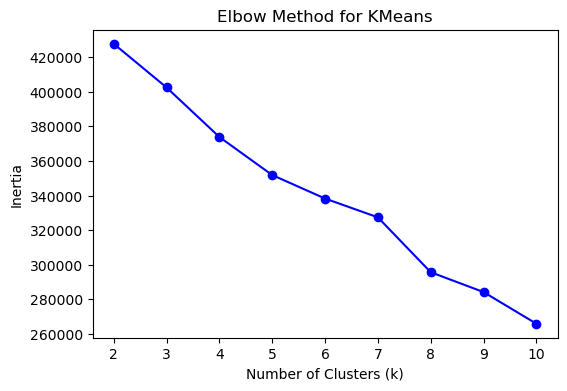

In [28]:
inertia = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, "bo-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

Using the Elbow Method for KMeans tell us where the sweet spot or how many clusters would be the most optimal 

The Inertia measures sum of squared distances from each song to it's cluster center so lower means tighter

We look at the "elblow" spot where it slowly levels off which is around cluster 5.

We pick this spot because any more clusters will give us dimishing return and not worth adding 

An interesting insight after cluster 7 has a steep drop which can indicate a second strong sub-group 


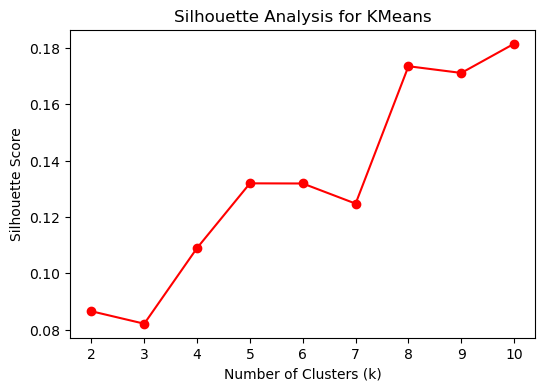

In [29]:
sil_scores = []
for k in K:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, "ro-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for KMeans")
plt.show()

We ran a Silhouetter Analysis to further confirm that cluster 5 was the "elbow" sweet spot

We also can see that 8-9 might be another sub-group 

In [30]:
best_k = 5 
km = KMeans(n_clusters=best_k, random_state=42)
df_pca['cluster_km'] = km.fit_predict(X)
df_raw['cluster_km'] = df_pca['cluster_km']

print("KMeans cluster sizes:")
print(df_raw['cluster_km'].value_counts())

KMeans cluster sizes:
cluster_km
4    8029
3    5843
0    5503
1    4946
2    4041
Name: count, dtype: int64


This trains the 5 cluster K-Means on the compressed PCA and report how many songs ended up in each cluster

We can see that cluster 4 has the highest song counts whereas cluster 2 has the lowest 

We can interpt this as cluster 4 being most common and cluster 2 being the most niche 

We can now look into 

In [31]:
# Pull out the 5 centroids from your KMeans model
centroids = km.cluster_centers_
centers_df = pd.DataFrame(
    centroids,
    columns=[f"PC{i+1}" for i in range(centroids.shape[1])]
)
print("Cluster centers (in PC space):")
display(centers_df)


Cluster centers (in PC space):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,-0.571382,0.493982,0.002160,1.703249,-0.426101,0.019722,0.198564,-0.108012,-0.020883,-0.083708,-0.046945,0.059557,-0.328474,-0.070257,0.044206
1,2.156561,-0.826579,0.113535,0.131721,-0.410998,0.243480,-0.321414,0.099627,0.009662,-0.147700,0.253748,-0.266420,0.238408,0.010004,-0.055906
2,-0.883821,-0.258269,1.386615,-0.353591,0.261493,-0.177548,-0.758868,1.103883,0.216083,-0.008994,-0.390525,0.094863,0.201146,0.419337,-0.067966
3,0.498533,1.292155,-0.615963,-0.702255,0.614781,-0.116540,0.149825,0.107201,0.447509,0.249468,-0.218671,0.142363,-0.405864,-0.274201,-0.148274
4,-0.854286,-0.640175,-0.320941,-0.559606,-0.033907,0.010738,0.334684,-0.620915,-0.426113,-0.028719,0.231645,-0.028140,0.272546,0.030530,0.146251


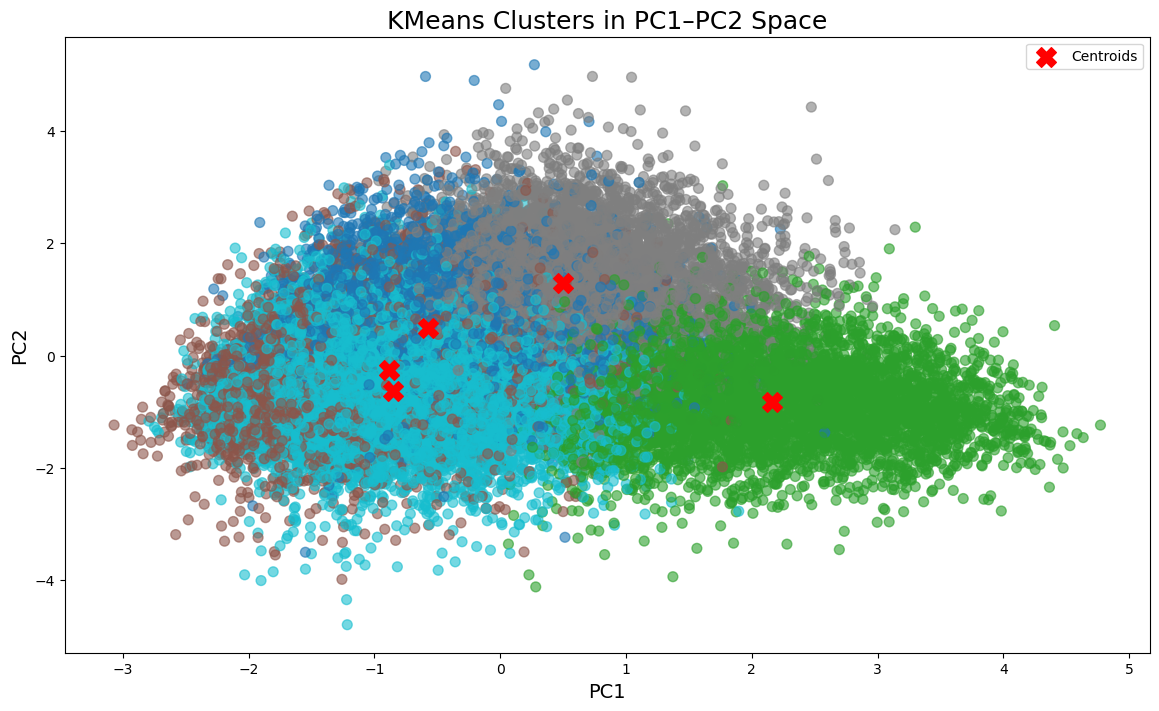

In [32]:
# 1. Scatter each song by its PC1/PC2, colored by cluster label
plt.figure(figsize=(14, 8))
plt.scatter(
    X[:, 0],            # PC1 values
    X[:, 1],            # PC2 values
    c=df_pca['cluster_km'],  # cluster assignment gives the color
    cmap='tab10',       # up to 10 distinct colors
    s=50,               # circle size
    alpha=0.6           # semi-transparent
)

# 2. Overlay the centroids
plt.scatter(
    centroids[:, 0],    # PC1 coords of centroids
    centroids[:, 1],    # PC2 coords of centroids
    color='red',
    marker='X',
    s=200,
    label='Centroids'
)

# 3. Labels, legend, and title
plt.title('KMeans Clusters in PC1–PC2 Space', fontsize=18)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.legend()
plt.show()


This maps out our PC 1 and PC 2 and recalling PC 1 was Long & Explicit vs Emotional where positive is long & explicit and PC 2 was mainly Violence vs Obscene.

We can see clear separation of clusters shown by different colors. 

We have a green cluster with high PC 1 meaning long & explicit but not violent being near 0 for PC 2

We also have a grey clsuter with moderate long & explicit but really high in violence

The red Centroids acts like anchors of each cluster showign their average point

With that being said, this validates our data showing clear separations of at least 4 clusters to give clear themes 

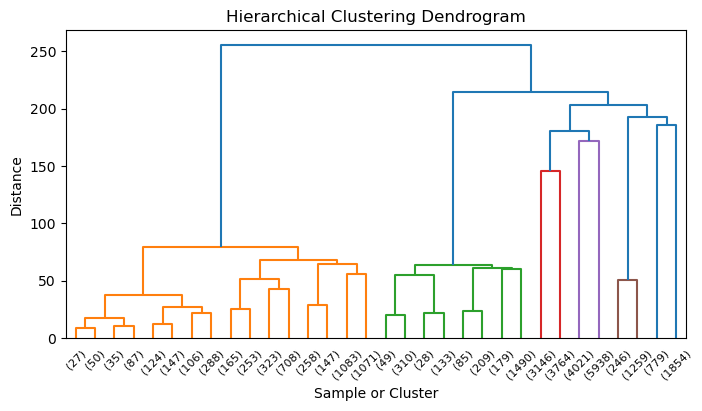

In [33]:
Z = linkage(X, method='ward')
plt.figure(figsize=(8,4))
dendrogram(Z, truncate_mode='level', p=4)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample or Cluster")
plt.ylabel("Distance")
plt.show()


This Dendrogram basically shows us how these songs are clsuted and merged together

Height of the two groups shows if they are short merges or tall merges meaning how close they are 

If we look at ~200-520 Distance we can see the orange and green clusters are far apart making orange its own macro-cluster

In [34]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df_pca['cluster_agg'] = agg.fit_predict(X)
df_raw['cluster_agg'] = df_pca['cluster_agg']

print("Agglomerative cluster sizes:")
print(df_raw['cluster_agg'].value_counts())


Agglomerative cluster sizes:
cluster_agg
1    16869
3     4872
0     2633
2     2483
4     1505
Name: count, dtype: int64


This is grabbing our PCA data and tags each song with its cluster ID and count how many songs fall into the 5 clusters

In [40]:
# Make sure df_raw has your cluster labels and metadata
# df_raw.columns should include ['cluster_agg','artist_name','track_name','genre', ...]

for c in sorted(df_raw['cluster_agg'].unique()):
    print(f"\n=== Cluster {c} ({(df_raw['cluster_agg']==c).sum()} songs) ===\n")
    subset = df_raw[df_raw['cluster_agg'] == c]
    display(
        subset[['artist_name','track_name','genre','cluster_agg']]
        .reset_index(drop=True)
    )



=== Cluster 0 (2633 songs) ===



,artist_name,track_name,genre,cluster_agg
0,the chordettes,carolina moon,pop,0
1,asha bhosle,awaz deta hai sola ka din,pop,0
2,lata mangeshkar,paas nahin aaiye haath na lagaiye,pop,0
3,andy williams,it's the most wonderful time of the year,pop,0
4,les paul,sleep,pop,0
...,...,...,...,...
2628,vince staples,big fish,hip hop,0
2629,kelly rowland,wonderful christmas time,hip hop,0
2630,vince staples,prima donna,hip hop,0
2631,aaliyah,are you that somebody,hip hop,0



=== Cluster 1 (16869 songs) ===



,artist_name,track_name,genre,cluster_agg
0,mukesh,mohabbat bhi jhoothi,pop,1
1,frankie laine,i believe,pop,1
2,perry como,round and round (with mitchell ayres and his o...,pop,1
3,freestyle,opm medley: when i met you,pop,1
4,johnny mathis,it's not for me to say,pop,1
...,...,...,...,...
16864,young mc,bust a move,hip hop,1
16865,will smith,men in black,hip hop,1
16866,t-pain,look at her go (feat. chris brown),hip hop,1
16867,q-tip,life is better,hip hop,1



=== Cluster 2 (2483 songs) ===



,artist_name,track_name,genre,cluster_agg
0,johnnie ray,cry,pop,2
1,les paul,blue skies,pop,2
2,les paul,smoke rings,pop,2
3,mukesh,hum tujhse mohabbat kar ke,pop,2
4,lata mangeshkar,main na janoon,pop,2
...,...,...,...,...
2478,fumez the engineer,pull up hop out bang,hip hop,2
2479,audio two,make it funky,hip hop,2
2480,shonlock,boggie bounce,hip hop,2
2481,gang starr,jazz thing,hip hop,2



=== Cluster 3 (4872 songs) ===



,artist_name,track_name,genre,cluster_agg
0,liva weel,"drømmer man om den, vågner..",pop,3
1,frankie laine,necessary evil,pop,3
2,les paul,chicken reel,pop,3
3,les paul,dark eyes,pop,3
4,asha bhosle,gullyachi shapath,pop,3
...,...,...,...,...
4867,mack 10,10 million ways,hip hop,3
4868,m.o.p.,ante up (robbin hoodz theory),hip hop,3
4869,nine,whutcha want?,hip hop,3
4870,will smith,switch,hip hop,3



=== Cluster 4 (1505 songs) ===



,artist_name,track_name,genre,cluster_agg
0,pérez prado,patricia,pop,4
1,giorgos papadopoulos,apopse eida oneiro,pop,4
2,stélios kazantzídis,klapse me mana klapse me,pop,4
3,les paul,the carioca,pop,4
4,ghantasala,ee jagamantha natika,pop,4
...,...,...,...,...
1500,tony yayo,pimpin',hip hop,4
1501,night shield,"monsters (cruelty 5) (feat. frank waln, young ...",hip hop,4
1502,t-rock,be a g about it,hip hop,4
1503,t-rock,4:20/reincarnated,hip hop,4


In [35]:
import joblib
import os

# Ensure a models/ directory exists
os.makedirs("models", exist_ok=True)

# Save the trained KMeans
joblib.dump(km, "models/kmeans.joblib")
print("Saved KMeans to models/kmeans.joblib")


Saved KMeans to models/kmeans.joblib
